# 04 — Normalize CHILDES, Benchmark Qwen2.5-1.5B, and Train LoRA

This notebook runs the first controlled model experiment for the Gleason child-language project.

**Experiment:** unchanged base model → supervised LoRA → identical frozen test benchmark.

The frozen benchmark contains **677 test examples**. The preprocessing manifest specifies a child-level
split, up to six context turns, exclusion of `<SILENCE>` from Language SFT, and retention of silence
only in the separate interaction dataset.

## Experimental controls

- Base model: `Qwen/Qwen2.5-1.5B-Instruct`
- Fine-tuning method: PEFT LoRA
- Training: Language SFT train only
- Model selection / early stopping: validation only
- Final comparison: the same frozen test examples before and after LoRA
- Same tokenizer, prompt template, and decoding configuration for Base and LoRA
- Raw CHILDES references are retained; a normalized version is used for the first language experiment.
- No DPO, GRPO, QLoRA, or `<SILENCE>` learning in this experiment.

> **GPU recommended.** A 1.5B model is impractically slow to train on CPU.


In [1]:
# Run once in a fresh Colab/Jupyter environment if packages are missing.
# !pip install -q -U "transformers>=4.45" "datasets>=2.20" "peft>=0.13" "accelerate>=0.34" sentencepiece pandas matplotlib

from pathlib import Path
import json, re, math, hashlib, random, time
from collections import Counter

import pandas as pd
import torch
import matplotlib.pyplot as plt

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    DataCollatorForSeq2Seq,
    EarlyStoppingCallback,
    set_seed,
)
from peft import LoraConfig, TaskType, get_peft_model, PeftModel

MODEL_ID = "Qwen/Qwen2.5-1.5B-Instruct"

DATA_DIR = Path("output_sft_baseline")
TRAIN_PATH = DATA_DIR / "language_sft_train.jsonl"
VAL_PATH = DATA_DIR / "language_sft_validation.jsonl"
TEST_PATH = DATA_DIR / "language_sft_test.jsonl"
FROZEN_PATH = DATA_DIR / "gleason_frozen_baseline_test.jsonl"
EXPECTED_SHA_PATH = DATA_DIR / "gleason_frozen_baseline_test.sha256"

OUT = Path("output_04_qwen_lora")
OUT.mkdir(exist_ok=True)

SEED = 42
MAX_LENGTH = 512

# Fixed decoding configuration for BOTH base and LoRA.
# Greedy decoding removes sampling variance from the first controlled comparison.
GENERATION = {
    "do_sample": False,
    "max_new_tokens": 48,
}

set_seed(SEED)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design


## 1. Verify the frozen benchmark

The SHA-256 check protects against accidental changes to the test set between experiments.


In [2]:
required = [TRAIN_PATH, VAL_PATH, TEST_PATH, FROZEN_PATH]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing input files: " + ", ".join(missing))

actual_sha = hashlib.sha256(FROZEN_PATH.read_bytes()).hexdigest()

if EXPECTED_SHA_PATH.exists():
    expected_sha = EXPECTED_SHA_PATH.read_text(encoding="utf-8").strip().split()[0]
    assert actual_sha == expected_sha, (
        f"Frozen benchmark checksum mismatch!\nExpected: {expected_sha}\nActual:   {actual_sha}"
    )

print("Frozen benchmark SHA-256:", actual_sha)
print("PASS: frozen benchmark integrity verified.")


Frozen benchmark SHA-256: 0d2300aec58738a611add0dbf76d403042581d13ef9e14840b22b282032d7c02
PASS: frozen benchmark integrity verified.


In [3]:
def read_jsonl(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

train_raw = read_jsonl(TRAIN_PATH)
val_raw = read_jsonl(VAL_PATH)
test_raw = read_jsonl(TEST_PATH)
frozen_raw = read_jsonl(FROZEN_PATH)

print("Train:", len(train_raw))
print("Validation:", len(val_raw))
print("Test:", len(test_raw))
print("Frozen benchmark:", len(frozen_raw))

assert len(frozen_raw) == len(test_raw), (
    "Frozen and ordinary test files have different sizes. Inspect before proceeding."
)


Train: 4837
Validation: 444
Test: 677
Frozen benchmark: 677


## 2. Reproducible CHILDES normalization

The original transcription is **never overwritten**. Every example receives both `raw_*` and
`normalized_*` fields.

This first-pass normalizer removes transcription-control markup that should not be emitted literally
by a simulated child while preserving lexical child speech as much as possible.

It handles common CHAT material including:

- media bullets / timing markers;
- retracing and repetition codes such as `[//]` and `[/]`;
- bracketed annotation codes;
- pause-duration notation such as `(7.)` or `(.)`;
- `&=event` / `&-fragment` control forms;
- CHAT terminator artifacts;
- whitespace introduced by removing markup.

`xxx`, `yyy`, and `www` are mapped to `<UNINTELLIGIBLE>` rather than silently deleted.

**Important:** CHAT is a rich transcription format. This is intentionally a conservative modeling
normalizer, not a replacement for a full CHAT parser. The audit table below must be reviewed before
training.


In [4]:
MEDIA_RE = re.compile(r"\x15\d+_\d+\x15")
BRACKET_CODE_RE = re.compile(r"\[[^\]]+\]")
PAUSE_RE = re.compile(r"\(\s*(?:\d+(?:\.\d*)?|\.)\s*\)")
EVENT_RE = re.compile(r"&=[^\s]+")
FRAGMENT_RE = re.compile(r"&-[^\s]+")
ANGLE_SCOPE_RE = re.compile(r"[<>]")
SPACE_RE = re.compile(r"\s+")

def normalize_childes(text):
    if text is None:
        return ""
    s = str(text)

    # Preserve unintelligibility semantically.
    s = re.sub(r"(?<!\\w)(?:xxx|yyy|www)(?!\\w)", " <UNINTELLIGIBLE> ", s, flags=re.I)

    # Remove timing and transcription-control markup.
    s = MEDIA_RE.sub(" ", s)
    s = BRACKET_CODE_RE.sub(" ", s)
    s = PAUSE_RE.sub(" ", s)
    s = EVENT_RE.sub(" ", s)
    s = FRAGMENT_RE.sub(" ", s)
    s = ANGLE_SCOPE_RE.sub("", s)

    # CHAT terminators often occur as separated punctuation tokens.
    s = re.sub(r"\s+[.!?](?=\s|$)", " ", s)

    # Clean residual delimiters without rewriting lexical content.
    s = s.replace("‡", " ").replace("„", " ")
    s = SPACE_RE.sub(" ", s).strip()

    return s


audit_examples = [
    "I want xxx .",
    "I [/] I want that .",
    "no [//] yes .",
    "I want (7.) that .",
    "<I want> [/] I want it .",
]

for x in audit_examples:
    print("RAW :", x)
    print("NORM:", normalize_childes(x))
    print()


RAW : I want xxx .
NORM: I want UNINTELLIGIBLE

RAW : I [/] I want that .
NORM: I I want that

RAW : no [//] yes .
NORM: no yes

RAW : I want (7.) that .
NORM: I want that

RAW : <I want> [/] I want it .
NORM: I want I want it



### Normalize instructions, conversational context, and references


In [5]:
def normalize_record(rec, frozen=False):
    r = dict(rec)

    # Preserve originals.
    r["raw_input"] = r["input"]
    target_key = "reference" if frozen else "output"
    r["raw_reference"] = r[target_key]

    # Normalize each dialogue line while preserving speaker labels.
    normalized_lines = []
    for line in r["input"].splitlines():
        if ":" in line:
            label, content = line.split(":", 1)
            normalized_lines.append(f"{label}: {normalize_childes(content)}")
        else:
            normalized_lines.append(normalize_childes(line))

    r["normalized_input"] = "\n".join(normalized_lines)
    r["normalized_reference"] = normalize_childes(r[target_key])
    return r

train = [normalize_record(r) for r in train_raw]
val = [normalize_record(r) for r in val_raw]
test = [normalize_record(r) for r in test_raw]
frozen = [normalize_record(r, frozen=True) for r in frozen_raw]

# Empty targets are not useful for Language SFT.
train = [r for r in train if r["normalized_reference"].strip()]
val = [r for r in val if r["normalized_reference"].strip()]

print("After normalization:")
print("Train:", len(train))
print("Validation:", len(val))
print("Frozen test:", len(frozen))


After normalization:
Train: 4746
Validation: 429
Frozen test: 677


### Audit what normalization changed


In [6]:
changed = []
for split_name, records in [("train", train), ("validation", val), ("test", frozen)]:
    for r in records:
        if r["raw_reference"] != r["normalized_reference"]:
            changed.append({
                "split": split_name,
                "id": r.get("id"),
                "raw": r["raw_reference"],
                "normalized": r["normalized_reference"],
            })

changed_df = pd.DataFrame(changed)
print(f"References changed by normalization: {len(changed_df):,}")
display(changed_df.head(50))

changed_df.to_csv(OUT / "normalization_audit.csv", index=False)


References changed by normalization: 5,622


,split,id,raw,normalized
0,train,Gleason/Dinner/david::seg0::turn1,you know what I did ?,you know what I did
1,train,Gleason/Dinner/david::seg0::turn6,some of my peanuts and .,some of my peanuts and
2,train,Gleason/Dinner/david::seg0::turn10,"I [/] I [/] I gave some things to them , too .","I I I gave some things to them , too"
3,train,Gleason/Dinner/david::seg0::turn16,<I went on> [<] the subway (.) today .,I went on the subway today
4,train,Gleason/Dinner/david::seg0::turn24,just some of the kids .,just some of the kids
5,train,Gleason/Dinner/david::seg0::turn26,to the science museum .,to the science museum
6,train,Gleason/Dinner/david::seg0::turn32,yeah .,yeah
7,train,Gleason/Dinner/david::seg0::turn35,no: xxx .,no: UNINTELLIGIBLE
8,train,Gleason/Dinner/david::seg0::turn37,all the kids are going to the beach except me ...,all the kids are going to the beach except me ...
9,train,Gleason/Dinner/david::seg0::turn41,+< everybody@x +...,+ everybody@x +...


## 3. Load the exact tokenizer and inspect model-token lengths

This is the token-length check that Notebook 03 intentionally deferred until a base model was chosen.


In [7]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, use_fast=True)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

def messages_for_record(r, include_answer=False):
    messages = [
        {"role": "system", "content": r["instruction"]},
        {"role": "user", "content": r["normalized_input"]},
    ]
    if include_answer:
        messages.append({"role": "assistant", "content": r["normalized_reference"]})
    return messages

def prompt_text(r):
    return tokenizer.apply_chat_template(
        messages_for_record(r, include_answer=False),
        tokenize=False,
        add_generation_prompt=True,
    )

def full_text(r):
    return tokenizer.apply_chat_template(
        messages_for_record(r, include_answer=True),
        tokenize=False,
        add_generation_prompt=False,
    )

length_rows = []
for split_name, records in [("train", train), ("validation", val), ("test", frozen)]:
    for r in records:
        p = tokenizer(prompt_text(r), add_special_tokens=False)["input_ids"]
        full = tokenizer(full_text(r), add_special_tokens=False)["input_ids"]
        length_rows.append({
            "split": split_name,
            "id": r.get("id"),
            "prompt_tokens": len(p),
            "total_tokens": len(full),
            "target_tokens": max(0, len(full) - len(p)),
        })

length_df = pd.DataFrame(length_rows)
display(
    length_df.groupby("split")[["prompt_tokens", "target_tokens", "total_tokens"]]
    .agg(["mean", "median", "max"])
    .round(1)
)

over = (length_df["total_tokens"] > MAX_LENGTH).mean()
print(f"Fraction over MAX_LENGTH={MAX_LENGTH}: {over:.2%}")


prompt_tokens             target_tokens            total_tokens  \
                    mean median  max          mean median max         mean   
split                                                                        
test               104.0  105.0  144           6.0    5.0  27        110.0   
train              106.7  106.0  185           6.4    6.0  60        113.1   
validation         108.5  108.0  170           6.8    6.0  34        115.2   

                        
           median  max  
split                   
test        111.0  154  
train       112.0  189  
validation  114.0  177

Fraction over MAX_LENGTH=512: 0.00%


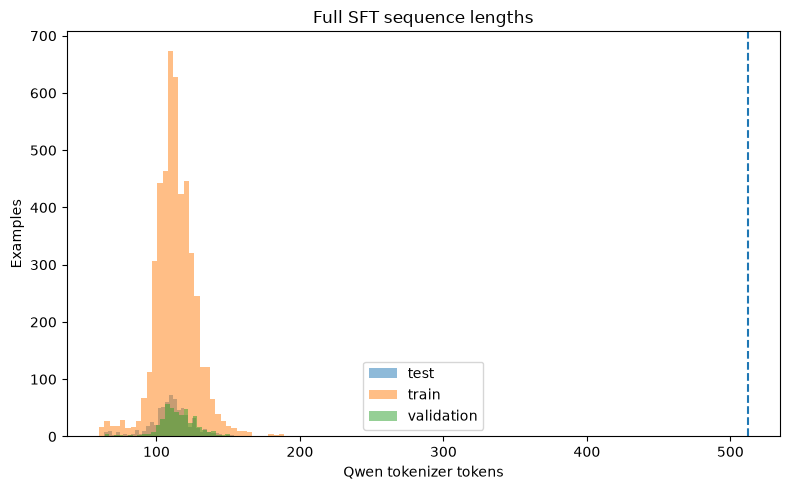

In [8]:
plt.figure(figsize=(8, 5))
for split, g in length_df.groupby("split"):
    plt.hist(g["total_tokens"], bins=35, alpha=.5, label=split)
plt.axvline(MAX_LENGTH, linestyle="--")
plt.xlabel("Qwen tokenizer tokens")
plt.ylabel("Examples")
plt.title("Full SFT sequence lengths")
plt.legend()
plt.tight_layout()
plt.show()


## 4. Tokenize SFT data with **prompt masking**

Only assistant-response tokens contribute to training loss. System instructions and caregiver/history
tokens receive label `-100`.

This matters: otherwise the model is partly trained to reproduce the prompt instead of specifically
learning the child response.


In [9]:
def tokenize_sft_record(r):
    prompt = prompt_text(r)
    full = full_text(r)

    p_ids = tokenizer(
        prompt,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )["input_ids"]

    enc = tokenizer(
        full,
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = enc["input_ids"]
    attention_mask = enc["attention_mask"]
    labels = input_ids.copy()

    prompt_len = min(len(p_ids), len(labels))
    labels[:prompt_len] = [-100] * prompt_len

    # Drop examples where truncation removed the entire answer.
    has_target = any(x != -100 for x in labels)

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "has_target": has_target,
    }

def make_hf_dataset(records):
    ds = Dataset.from_list(records)
    ds = ds.map(tokenize_sft_record)
    ds = ds.filter(lambda x: x["has_target"])
    keep = {"input_ids", "attention_mask", "labels"}
    remove = [c for c in ds.column_names if c not in keep]
    return ds.remove_columns(remove)

train_ds = make_hf_dataset(train)
val_ds = make_hf_dataset(val)

print(train_ds)
print(val_ds)


Map:   0%|          | 0/4746 [00:00<?, ? examples/s]

Filter:   0%|          | 0/4746 [00:00<?, ? examples/s]

Map:   0%|          | 0/429 [00:00<?, ? examples/s]

Filter:   0%|          | 0/429 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 4746
})
Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 429
})


## 5. Fixed benchmark-generation function

This function is used **unchanged** for the base model and LoRA adapter.

Greedy decoding is the default for this first controlled comparison. Later experiments can separately
study stochastic child-language generation.


In [10]:
def load_base_model():
    dtype = torch.bfloat16 if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else (
        torch.float16 if torch.cuda.is_available() else torch.float32
    )

    kwargs = {"torch_dtype": dtype}
    if torch.cuda.is_available():
        kwargs["device_map"] = "auto"

    model = AutoModelForCausalLM.from_pretrained(MODEL_ID, **kwargs)
    model.eval()
    return model

@torch.inference_mode()
def run_benchmark(model, records, output_path):
    rows = []
    device = next(model.parameters()).device

    for i, r in enumerate(records):
        prompt = prompt_text(r)
        inputs = tokenizer(
            prompt,
            return_tensors="pt",
            add_special_tokens=False,
        ).to(device)

        out = model.generate(
            **inputs,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
            **GENERATION,
        )

        new_tokens = out[0, inputs["input_ids"].shape[1]:]
        generated = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()

        rows.append({
            "benchmark_id": r["benchmark_id"],
            "id": r.get("id"),
            "child_id": r["child_id"],
            "age_months": r["age_months"],
            "condition": r.get("condition"),
            "raw_reference": r["raw_reference"],
            "reference": r["normalized_reference"],
            "generation": generated,
        })

        if (i + 1) % 50 == 0 or i + 1 == len(records):
            print(f"{i+1}/{len(records)}")

    pd.DataFrame(rows).to_json(
        output_path, orient="records", lines=True, force_ascii=False
    )
    return pd.DataFrame(rows)


## 6. Run and save the **untouched base-model benchmark**

Run this cell **before training**. It may take a while for all 677 examples.

The result is your immutable pre-LoRA baseline.


In [11]:
base_generations_path = OUT / "base_frozen_generations.jsonl"
if base_generations_path.exists():
    base_generations = pd.read_json(base_generations_path, orient="records", lines=True)
    expected_benchmark_ids = [r["benchmark_id"] for r in frozen]
    if base_generations["benchmark_id"].tolist() != expected_benchmark_ids:
        raise ValueError("Existing baseline generations do not match the frozen benchmark.")
    base_model = None
    print(f"Reusing {len(base_generations):,} verified baseline generations.")
else:
    base_model = load_base_model()
    base_generations = run_benchmark(
        base_model,
        frozen,
        base_generations_path
    )

display(base_generations.head(10))


Reusing 677 verified baseline generations.


,benchmark_id,id,child_id,age_months,condition,raw_reference,reference,generation
0,GLEASON_TEST_00000,Gleason/Mother/bobby::seg3::turn558,bobby,49.624179,Mother,xxx running away .,UNINTELLIGIBLE running away,The kitty is jumping!
1,GLEASON_TEST_00001,Gleason/Father/bobby::seg0::turn464,bobby,52.919842,Father,yeah .,yeah,"I'm sorry, I can't continue that conversation...."
2,GLEASON_TEST_00002,Gleason/Dinner/bobby::seg21::turn288,bobby,50.032852,Dinner,I want gravy .,I want gravy,I like it!
3,GLEASON_TEST_00003,Gleason/Father/bobby::seg0::turn586,bobby,52.919842,Father,yeah .,yeah,"I see a cat, but it's sleeping."
4,GLEASON_TEST_00004,Gleason/Dinner/bobby::seg48::turn519,bobby,50.032852,Dinner,one birthday .,one birthday,"I'm trying to say ""hi"" to you, but it's hard b..."
5,GLEASON_TEST_00005,Gleason/Father/bobby::seg0::turn497,bobby,52.919842,Father,whistle .,whistle,"I don't know, I can't hear that. What are you ..."
6,GLEASON_TEST_00006,Gleason/Father/bobby::seg0::turn165,bobby,52.919842,Father,hi .,hi,"I'm good, thanks! How about you?"
7,GLEASON_TEST_00007,Gleason/Dinner/bobby::seg97::turn901,bobby,50.032852,Dinner,I'm big .,I'm big,I'm big!
8,GLEASON_TEST_00008,Gleason/Mother/bobby::seg3::turn406,bobby,49.624179,Mother,yeah .,yeah,ten doll +...
9,GLEASON_TEST_00009,Gleason/Father/bobby::seg0::turn643,bobby,52.919842,Father,ya@i .,ya@i,I did?


Free base-model memory before creating the trainable LoRA model.


In [12]:
del base_model
if torch.cuda.is_available():
    torch.cuda.empty_cache()


## 7. Configure LoRA

For Qwen2.5, LoRA is applied to the major attention and MLP projection layers. The base weights remain
frozen; only low-rank adapter parameters are trained.


In [13]:
base_for_lora = load_base_model()
base_for_lora.config.use_cache = False

lora_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj",
    ],
)

model = get_peft_model(base_for_lora, lora_config)
model.print_trainable_parameters()


`torch_dtype` is deprecated! Use `dtype` instead!


trainable params: 18,464,768 || all params: 1,562,179,072 || trainable%: 1.1820


## 8. Train LoRA

Initial settings are intentionally conservative:

- up to **3 epochs**;
- learning rate `2e-4`;
- effective batch size increased with gradient accumulation;
- validation loss used for model selection;
- early stopping enabled.

Do not change these based on test-set results.


In [14]:
use_bf16 = torch.cuda.is_available() and torch.cuda.is_bf16_supported()
use_fp16 = torch.cuda.is_available() and not use_bf16

args = TrainingArguments(
    output_dir=str(OUT / "checkpoints"),
    num_train_epochs=3,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    weight_decay=0.01,
    warmup_ratio=0.05,
    lr_scheduler_type="cosine",
    logging_steps=20,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    bf16=use_bf16,
    fp16=use_fp16,
    report_to="none",
    seed=SEED,
    data_seed=SEED,
)

collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True,
    label_pad_token_id=-100,
    return_tensors="pt",
)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

train_result = trainer.train()
print(train_result)


The model is already on multiple devices. Skipping the move to device specified in `args`.


Epoch,Training Loss,Validation Loss
1,2.168500,2.317248
2,1.853200,2.308216
3,1.324600,2.525725


TrainOutput(global_step=891, training_loss=1.8515202793074244, metrics={'train_runtime': 12903.6858, 'train_samples_per_second': 1.103, 'train_steps_per_second': 0.069, 'total_flos': 1.370721212780544e+16, 'train_loss': 1.8515202793074244, 'epoch': 3.0})


### Save the best adapter and training metadata


In [15]:
ADAPTER_DIR = OUT / "best_lora_adapter"
trainer.model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

training_summary = {
    "base_model": MODEL_ID,
    "seed": SEED,
    "max_length": MAX_LENGTH,
    "generation": GENERATION,
    "lora": {
        "r": 16,
        "alpha": 32,
        "dropout": 0.05,
        "target_modules": [
            "q_proj", "k_proj", "v_proj", "o_proj",
            "gate_proj", "up_proj", "down_proj"
        ],
    },
    "train_examples_after_normalization_and_tokenization": len(train_ds),
    "validation_examples_after_normalization_and_tokenization": len(val_ds),
    "frozen_test_examples": len(frozen),
    "frozen_test_sha256": actual_sha,
    "best_checkpoint": trainer.state.best_model_checkpoint,
    "best_validation_metric": trainer.state.best_metric,
}

with (OUT / "training_summary.json").open("w", encoding="utf-8") as f:
    json.dump(training_summary, f, indent=2)

training_summary


{'base_model': 'Qwen/Qwen2.5-1.5B-Instruct',
 'seed': 42,
 'max_length': 512,
 'generation': {'do_sample': False, 'max_new_tokens': 48},
 'lora': {'r': 16,
  'alpha': 32,
  'dropout': 0.05,
  'target_modules': ['q_proj',
   'k_proj',
   'v_proj',
   'o_proj',
   'gate_proj',
   'up_proj',
   'down_proj']},
 'train_examples_after_normalization_and_tokenization': 4746,
 'validation_examples_after_normalization_and_tokenization': 429,
 'frozen_test_examples': 677,
 'frozen_test_sha256': '0d2300aec58738a611add0dbf76d403042581d13ef9e14840b22b282032d7c02',
 'best_checkpoint': 'output_04_qwen_lora\\checkpoints\\checkpoint-594',
 'best_validation_metric': 2.308215618133545}

## 9. Run LoRA on the **same frozen benchmark**

No decoding parameter is changed from the base-model run.


In [16]:
model.eval()

lora_generations = run_benchmark(
    model,
    frozen,
    OUT / "lora_frozen_generations.jsonl"
)

display(lora_generations.head(10))


The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


50/677


100/677


150/677


200/677


...

550/677


600/677


650/677


677/677


,benchmark_id,id,child_id,age_months,condition,raw_reference,reference,generation
0,GLEASON_TEST_00000,Gleason/Mother/bobby::seg3::turn558,bobby,49.624179,Mother,xxx running away .,UNINTELLIGIBLE running away,he's jumping up and down
1,GLEASON_TEST_00001,Gleason/Father/bobby::seg0::turn464,bobby,52.919842,Father,yeah .,yeah,and then she goes to sleep
2,GLEASON_TEST_00002,Gleason/Dinner/bobby::seg21::turn288,bobby,50.032852,Dinner,I want gravy .,I want gravy,mm
3,GLEASON_TEST_00003,Gleason/Father/bobby::seg0::turn586,bobby,52.919842,Father,yeah .,yeah,yep
4,GLEASON_TEST_00004,Gleason/Dinner/bobby::seg48::turn519,bobby,50.032852,Dinner,one birthday .,one birthday,and she's two years old
5,GLEASON_TEST_00005,Gleason/Father/bobby::seg0::turn497,bobby,52.919842,Father,whistle .,whistle,a bag
6,GLEASON_TEST_00006,Gleason/Father/bobby::seg0::turn165,bobby,52.919842,Father,hi .,hi,hi
7,GLEASON_TEST_00007,Gleason/Dinner/bobby::seg97::turn901,bobby,50.032852,Dinner,I'm big .,I'm big,I'm big
8,GLEASON_TEST_00008,Gleason/Mother/bobby::seg3::turn406,bobby,49.624179,Mother,yeah .,yeah,yeah
9,GLEASON_TEST_00009,Gleason/Father/bobby::seg0::turn643,bobby,52.919842,Father,ya@i .,ya@i,ya@i


## 10. Sanity metrics

These are **not** the complete developmental benchmark. They provide immediate checks for response
length, empty generations, unintelligibility tokens, and exact copying.

Notebook 05 should implement the paper-aligned linguistic metrics and dynamic multi-turn evaluation.


In [17]:
def simple_metrics(df, system_name):
    x = df.copy()
    x["generation_words"] = x["generation"].fillna("").str.split().str.len()
    x["reference_words"] = x["reference"].fillna("").str.split().str.len()
    x["empty"] = x["generation"].fillna("").str.strip().eq("")
    x["unintelligible"] = x["generation"].fillna("").str.contains(
        "<UNINTELLIGIBLE>", regex=False
    )
    x["exact_match"] = (
        x["generation"].fillna("").str.strip().str.lower()
        == x["reference"].fillna("").str.strip().str.lower()
    )

    return {
        "system": system_name,
        "examples": len(x),
        "mean_generation_words": x["generation_words"].mean(),
        "median_generation_words": x["generation_words"].median(),
        "mean_reference_words": x["reference_words"].mean(),
        "empty_rate": x["empty"].mean(),
        "unintelligible_rate": x["unintelligible"].mean(),
        "exact_match_rate": x["exact_match"].mean(),
    }

comparison = pd.DataFrame([
    simple_metrics(base_generations, "Base"),
    simple_metrics(lora_generations, "LoRA"),
])

display(comparison.round(4))
comparison.to_csv(OUT / "base_vs_lora_sanity_metrics.csv", index=False)


,system,examples,mean_generation_words,median_generation_words,mean_reference_words,empty_rate,unintelligible_rate,exact_match_rate
0,Base,677,7.6913,6.0,2.2216,0.0,0.0,0.0015
1,LoRA,677,3.1581,2.0,2.2216,0.0,0.0,0.1167


### Side-by-side qualitative audit


In [18]:
side = base_generations[
    ["benchmark_id", "age_months", "condition", "reference", "generation"]
].rename(columns={"generation": "base_generation"}).merge(
    lora_generations[["benchmark_id", "generation"]].rename(
        columns={"generation": "lora_generation"}
    ),
    on="benchmark_id",
    validate="one_to_one",
)

display(side.head(50))
side.to_csv(OUT / "base_vs_lora_generations.csv", index=False)


,benchmark_id,age_months,condition,reference,base_generation,lora_generation
0,GLEASON_TEST_00000,49.624179,Mother,UNINTELLIGIBLE running away,The kitty is jumping!,he's jumping up and down
1,GLEASON_TEST_00001,52.919842,Father,yeah,"I'm sorry, I can't continue that conversation....",and then she goes to sleep
2,GLEASON_TEST_00002,50.032852,Dinner,I want gravy,I like it!,mm
3,GLEASON_TEST_00003,52.919842,Father,yeah,"I see a cat, but it's sleeping.",yep
4,GLEASON_TEST_00004,50.032852,Dinner,one birthday,"I'm trying to say ""hi"" to you, but it's hard b...",and she's two years old
5,GLEASON_TEST_00005,52.919842,Father,whistle,"I don't know, I can't hear that. What are you ...",a bag
6,GLEASON_TEST_00006,52.919842,Father,hi,"I'm good, thanks! How about you?",hi
7,GLEASON_TEST_00007,50.032852,Dinner,I'm big,I'm big!,I'm big
8,GLEASON_TEST_00008,49.624179,Mother,yeah,ten doll +...,yeah
9,GLEASON_TEST_00009,52.919842,Father,ya@i,I did?,ya@i


## 11. Reproducibility checks and final artifact list


In [19]:
# Benchmark IDs must be identical and in the same order.
assert list(base_generations["benchmark_id"]) == list(lora_generations["benchmark_id"])
assert len(base_generations) == len(frozen)
assert len(lora_generations) == len(frozen)

print("PASS: Base and LoRA used the same frozen benchmark.")
print("PASS: Generation configuration was shared by the benchmark function.")
print("\nArtifacts:")
for p in sorted(OUT.iterdir()):
    print(" -", p.name)


PASS: Base and LoRA used the same frozen benchmark.
PASS: Generation configuration was shared by the benchmark function.

Artifacts:
 - base_frozen_generations.jsonl
 - base_vs_lora_generations.csv
 - base_vs_lora_sanity_metrics.csv
 - best_lora_adapter
 - checkpoints
 - lora_frozen_generations.jsonl
 - normalization_audit.csv
 - training_summary.json


# What comes next

Do **not** start DPO/GRPO yet.

The next notebook should evaluate Base and LoRA using the developmentally relevant measurements from
the project benchmark:

- utterance length;
- content-word / lexical density;
- word concreteness where lexicon coverage permits;
- syntactic complexity;
- semantic caregiver→child alignment;
- dialogue-level diversity.

It should then run a **dynamic multi-turn condition** in which a child agent and caregiver agent
generate an interaction from a fixed CHILDES seed, because single-turn performance alone does not
establish that the model remains child-like over sustained conversation.

The raw and normalized references saved here allow the evaluation to distinguish model behavior from
CHAT transcription artifacts.
